1. Problem defining
- The problem statement is to identify gold prices based on past data.
- if the good accuracy is achieved both in training and test, the project prediction is considered as successful.
- The target varible will be gold prices - means we will be dealing with supervised learning algorithm and also algorthm which are used in regression analyses.


2. Data Collection
- Dataset is Gold price Data from https://www.kaggle.com/datasets/altruistdelhite04/gold-price-data
- Date - date (MM/dd/yyyy format)
- SPX - stands for The Standard and Poor's 500 index, or simply the S&P 500. It is a stock market index used for tracking the stock performance of 500 of the largest companies listed on stock exchanges in USA
- GLD - gold price
- USO - stands for "The United States Oil Fund ® LP (USO)". It is an exchange-traded security whose shares may be purchased and sold on the NYSE Arca
- SLV - silver price
- EUR/USD - Euro to US dollar exchange ratio

In [2]:
import pandas as pd
data = pd.read_csv('gld_price_data.csv')
data.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


3. Exploratory Data Analysis (EDA)
- Analyzing class distribution (check for imbalance)
- Examining missing values patterns
- Identifing outliers and anomalies
- Analyzing correlations between features
- Visualizing data
- Checking for multicollinearity among predictors

In [3]:
data.shape

(2290, 6)

In [5]:
data.isnull().sum()

,0
Date,0
SPX,0
GLD,0
USO,0
SLV,0
EUR/USD,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Date     2290 non-null   object 
 1   SPX      2290 non-null   float64
 2   GLD      2290 non-null   float64
 3   USO      2290 non-null   float64
 4   SLV      2290 non-null   float64
 5   EUR/USD  2290 non-null   float64
dtypes: float64(5), object(1)
memory usage: 107.5+ KB


In [7]:
data.describe()

,SPX,GLD,USO,SLV,EUR/USD
count,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,1654.315776,122.732875,31.842221,20.084997,1.283653
std,519.111540,23.283346,19.523517,7.092566,0.131547
min,676.530029,70.000000,7.960000,8.850000,1.039047
25%,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2872.870117,184.589996,117.480003,47.259998,1.598798


<Axes: >

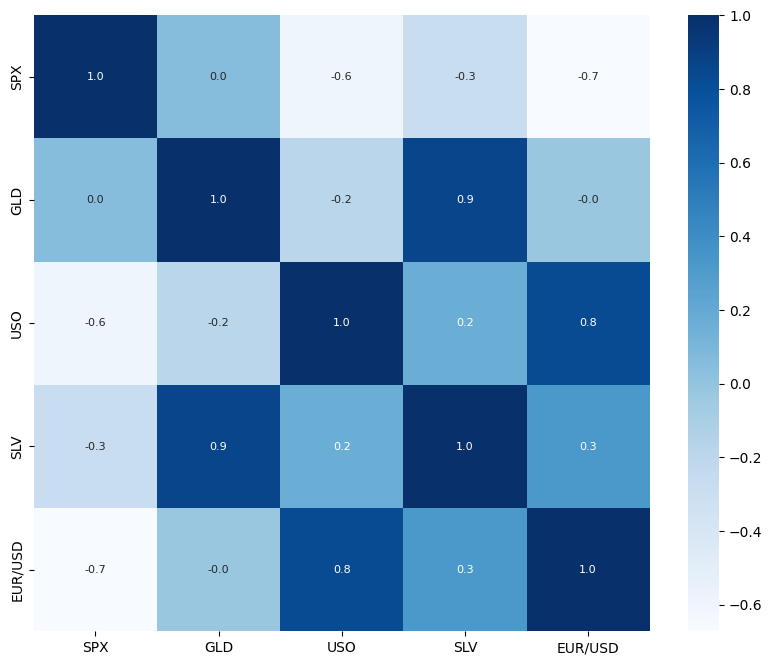

In [16]:
correlation = data.corr(numeric_only=True)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(correlation,cbar=True, square=True, fmt='.1f', annot=True, annot_kws={'size':8}, cmap='Blues')

In [17]:
#correlation values of Gold prices
correlation['GLD']

,GLD
SPX,0.049345
GLD,1.000000
USO,-0.186360
SLV,0.866632
EUR/USD,-0.024375


<Figure size 100x100 with 0 Axes>

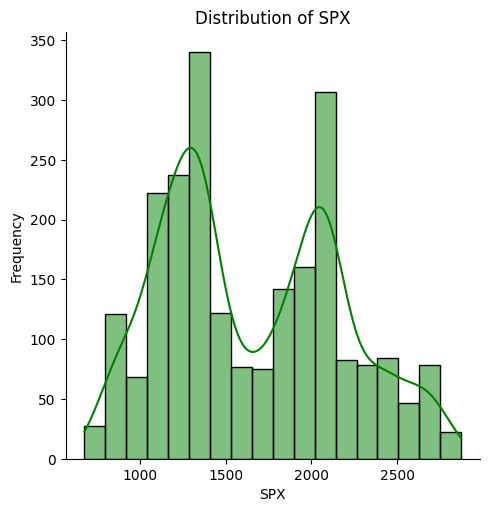

<Figure size 100x100 with 0 Axes>

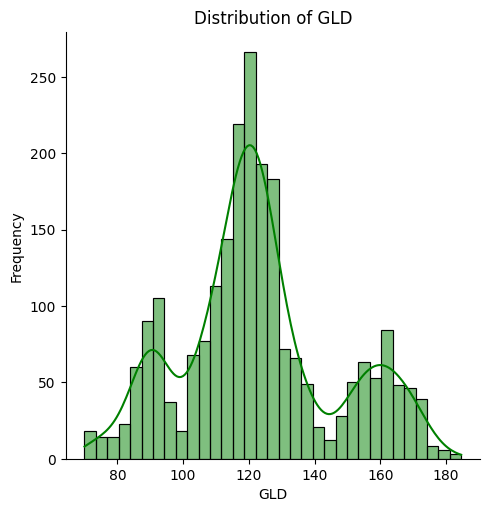

<Figure size 100x100 with 0 Axes>

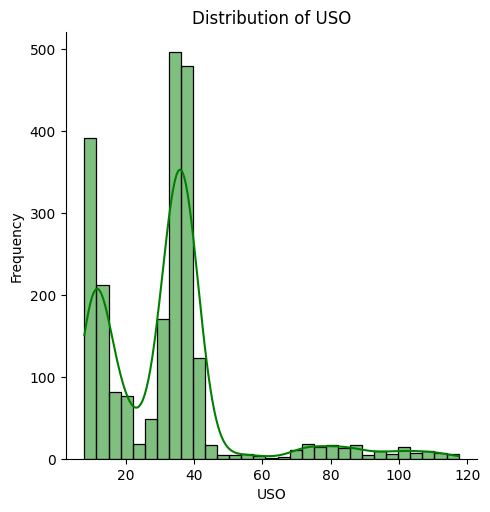

<Figure size 100x100 with 0 Axes>

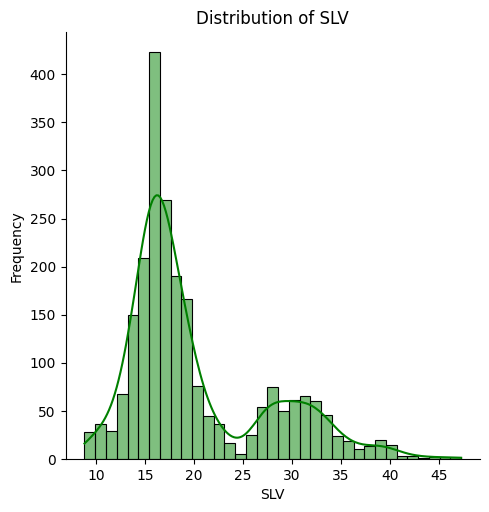

<Figure size 100x100 with 0 Axes>

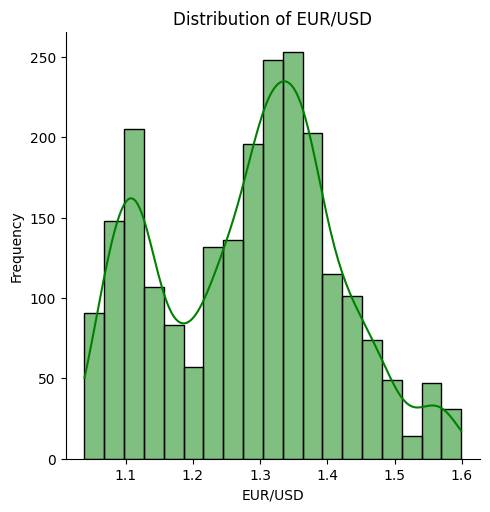

In [26]:
numerical_cols = data.select_dtypes(include=['float64', 'int64']).columns

for col in numerical_cols:
    plt.figure(figsize=(1,1))
    sns.displot(data[col], kde=True, color='Green')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

<Axes: xlabel='GLD'>

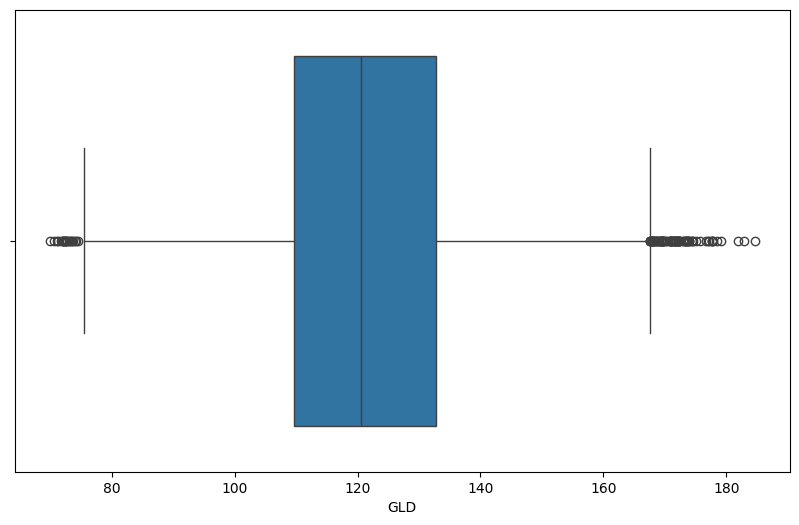

In [32]:
IQR = data['GLD'].quantile(0.75) - data['GLD'].quantile(0.25)
lower_bound = data['GLD'].quantile(0.25) - 1.5 * IQR
upper_bound = data['GLD'].quantile(0.75) + 1.5 * IQR
outliers = data[(data['GLD'] < lower_bound) | (data['GLD'] > upper_bound)]
plt.figure(figsize=(10,6))
sns.boxplot(x=data['GLD'])

Observation:
- The dataset contain 2290 rows and 6 columns
- The dataset dont have missing values.
- data.info() shows that all columns except date are present in float type
- By heatmap, we observe that some columns have postive and some columns have negative correlation between them. For example: SPX to EUR/USD and SLV have negative correlation while SLV to GLD have high correlation.
- Our Target variable (GLD) have 0.8 correlation with SLV.
- In class distribution graph, we can see the high and fall of values of each column over a period of time.

4. Removing Irrelevant Column



In [33]:
data = data.drop('Date',axis=1)
data.head()

,SPX,GLD,USO,SLV,EUR/USD
0,1447.160034,84.860001,78.470001,15.180,1.471692
1,1447.160034,85.570000,78.370003,15.285,1.474491
2,1411.630005,85.129997,77.309998,15.167,1.475492
3,1416.180054,84.769997,75.500000,15.053,1.468299
4,1390.189941,86.779999,76.059998,15.590,1.557099


5. Model Building
- The condition to shoose a model:
  - As we already have target price which tells us we are dealing with labelled data.
  - The target column is a number which tells us we need regression analyses
  - We have multiple features in a data that are correlated to gold prices and can affect the prediction of gold prices if those features are not included in the training set.
- Therefore, Looking at the condition. It would be best to use RandomForestRegressor algorithm to our dataset.


In [47]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [35]:
x = data.drop('GLD',axis=1)
y = data['GLD']

In [37]:
x.head()

,SPX,USO,SLV,EUR/USD
0,1447.160034,78.470001,15.180,1.471692
1,1447.160034,78.370003,15.285,1.474491
2,1411.630005,77.309998,15.167,1.475492
3,1416.180054,75.500000,15.053,1.468299
4,1390.189941,76.059998,15.590,1.557099


In [38]:
y.head()

,GLD
0,84.860001
1,85.570000
2,85.129997
3,84.769997
4,86.779999


In [39]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state = 10)

In [40]:
regressor = RandomForestRegressor(n_estimators=100)
regressor.fit(x_train, y_train)

RandomForestRegressor()

6. Model Evaluation & Validation
- Using Regression evaluation metrics for evaluating model performances.
- Checking for the occurance of overfitting and underfitting by train and test


In [42]:
test_data = regressor.predict(x_test)

In [45]:
error = mean_squared_error(y_test, test_data)
print(f'Mean Squared Error: {error}')

Mean Squared Error: 6.4239763762380155


In [48]:
r2 = r2_score(y_test, test_data)
print(f'R-squared: {r2}')


R-squared: 0.9896139531670699


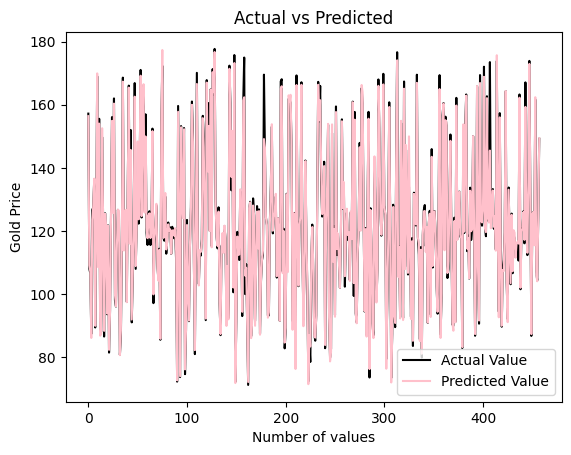

In [54]:
y_test = list(y_test)
plt.plot(y_test, color='Black',label="Actual Value")
plt.plot(test_data, color='pink', label='Predicted Value')
plt.title('Actual vs Predicted')
plt.xlabel('Number of values')
plt.ylabel('Gold Price')
plt.legend()

Observation:
- As we can see the actual and predicted points are really close
- We can say that our predictions is successfully done.